In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:

import seaborn as sns
# Load Titanic dataset
df = sns.load_dataset("titanic")

# Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Load Titanic dataset
df = sns.load_dataset("titanic")

# Save a local copy
df.to_csv("titanic.csv", index=False)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print("Shape of Dataset:", df.shape)
print("\n")

df.info()


Shape of Dataset: (891, 15)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


In [7]:
# Fill age with median
df["age"] = df["age"].fillna(df["age"].median())

# Fill embarked with mode
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Fill embark_town with mode
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

# Drop deck because it has many missing values
df.drop(columns=["deck"], inplace=True)

print(df.isnull().sum())


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


#Missing Value Strategy
The age column contains numerical data, so missing values are filled with the median because it is less affected by outliers.

The embarked and embark_town columns contain categorical data, so missing values are filled with the mode (most frequent value).

The deck column has a very high percentage of missing values, so it is removed from the dataset


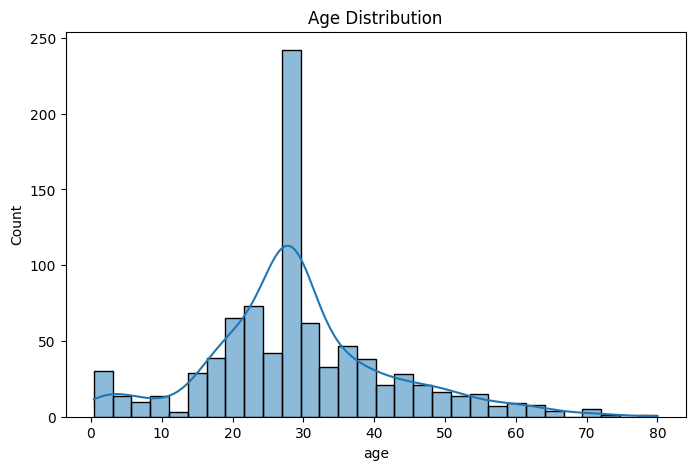

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.show()

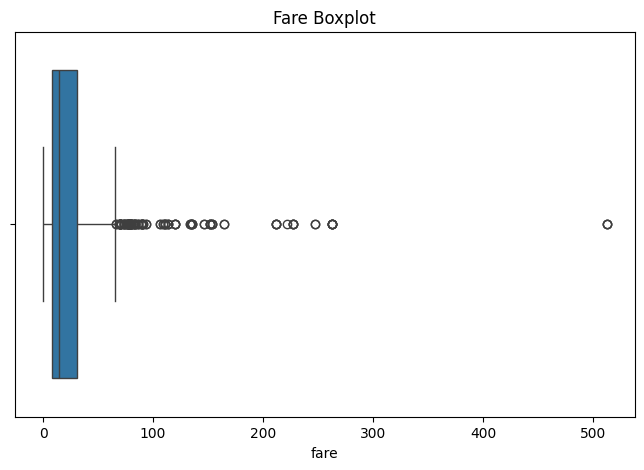

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["fare"])

plt.title("Fare Boxplot")
plt.show()

In [10]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["fare"] < lower) | (df["fare"] > upper)]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 116


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,Southampton,no,False
31,1,1,female,28.0,1,0,146.5208,C,First,woman,False,Cherbourg,yes,False
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,Cherbourg,no,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,Cherbourg,yes,False


In [11]:
print("Age Statistics")
print("Mean   :", df["age"].mean())
print("Median :", df["age"].median())
print("Mode   :", df["age"].mode()[0])

print("\nFare Statistics")
print("Mean   :", df["fare"].mean())
print("Median :", df["fare"].median())
print("Mode   :", df["fare"].mode()[0])

Age Statistics
Mean   : 29.36158249158249
Median : 28.0
Mode   : 28.0

Fare Statistics
Mean   : 32.204207968574636
Median : 14.4542
Mode   : 8.05


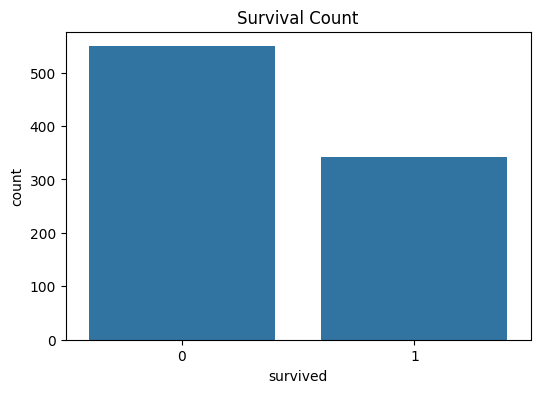

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="survived")

plt.title("Survival Count")
plt.show()

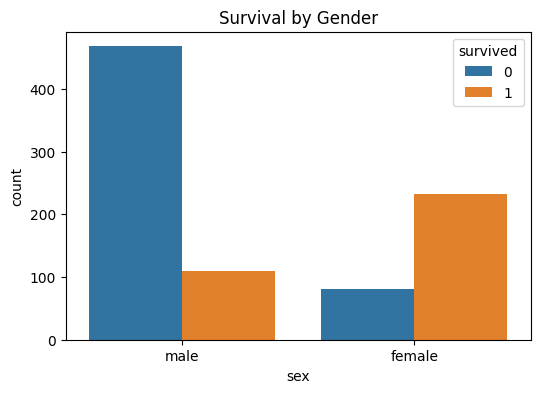

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sex", hue="survived")

plt.title("Survival by Gender")
plt.show()

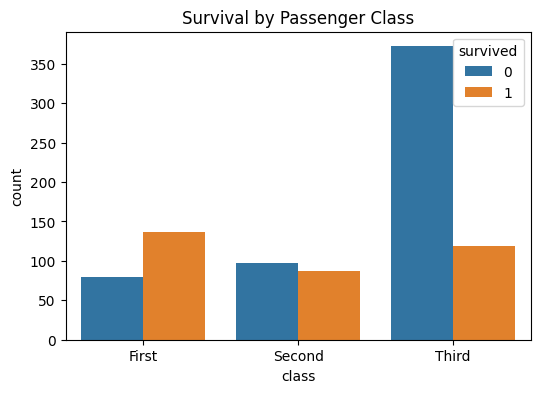

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="class", hue="survived")

plt.title("Survival by Passenger Class")
plt.show()

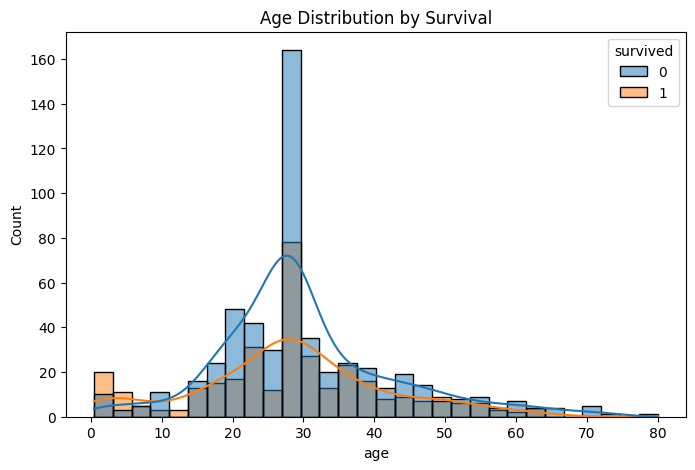

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="survived", kde=True)

plt.title("Age Distribution by Survival")
plt.show()

In [16]:
numeric_df = df.select_dtypes(include=["number"])

correlation = numeric_df.corr()

correlation

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


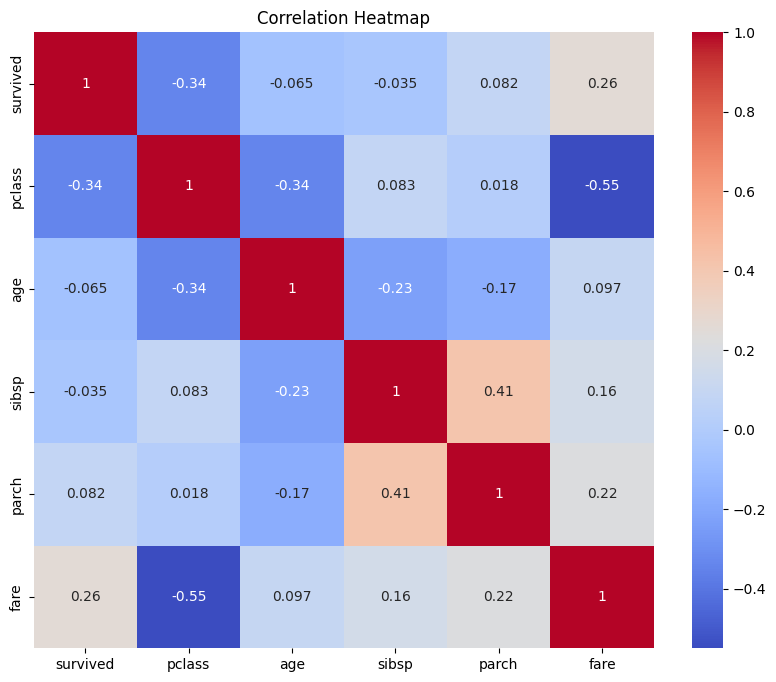

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [18]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[["age", "fare"]])

scaled_df = pd.DataFrame(
    scaled_data,
    columns=["age_scaled", "fare_scaled"]
)

scaled_df.head()

,age_scaled,fare_scaled
0,-0.565736,-0.502445
1,0.663861,0.786845
2,-0.258337,-0.488854
3,0.433312,0.420730
4,0.433312,-0.486337


In [19]:
comparison = pd.concat(
    [
        df[["age", "fare"]].head(),
        scaled_df.head()
    ],
    axis=1
)

comparison

,age,fare,age_scaled,fare_scaled
0,22.0,7.2500,-0.565736,-0.502445
1,38.0,71.2833,0.663861,0.786845
2,26.0,7.9250,-0.258337,-0.488854
3,35.0,53.1000,0.433312,0.420730
4,35.0,8.0500,0.433312,-0.486337


## Conclusion

- The Titanic dataset contains missing values in the Age, Embarked, Embark Town, and Deck columns.
- Missing values were handled using the median for numerical data, the mode for categorical data, and the Deck column was removed due to excessive missing values.
- Female passengers had a much higher survival rate than male passengers.
- First-class passengers were more likely to survive than passengers in lower classes.
- The Fare column contains several outliers.
- Standardization was applied to the Age and Fare columns to prepare them for machine learning models.